In [95]:
from langgraph.graph import StateGraph ,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [96]:
class QuadraticState(TypedDict):
  a:int
  b:int
  c:int

  equation:str
  discriminant:float
  result:str

In [97]:
def show_equation(state:QuadraticState):
  equation=f"{state['a']}x2{state['b']}x{state['c']}"

  return {'equation':equation}

In [98]:
def calculate_discriminant(state:QuadraticState):
  descriminant=state['b']**2 -(4*state['a']*state['c'])
  return{'discriminant':descriminant}

In [99]:
def real_root(state:QuadraticState):
  root1=(-state['b']+state['discriminant']**0.5)/(2*state['a'])
  root2=(-state['b']-state['discriminant']**0.5)/(2*state['a'])

  result=f"The roots are {root1} and {root2}"

  return {'result':result}

In [100]:
def repeated_root(state:QuadraticState):
    root1=(-state['b'])/(2*state['a'])

    result=f"The only repeating root is {root1}"

    return {'result':result}

In [101]:
def no_real_root(state:QuadraticState):
  result=f"No real roots"

  return {'result':result}

In [102]:
def check_condtion(state:QuadraticState) -> Literal["real_root" ,'repeated_root','no_real_root']:
  if state['discriminant'] > 0:
    return "real_root"
  elif state['discriminant'] == 0:
    return 'repeated_root'
  else:
    return 'no_real_root'

In [103]:
graph=StateGraph(QuadraticState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_root',real_root)
graph.add_node('repeated_root',repeated_root)
graph.add_node('no_real_root',no_real_root)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condtion)
graph.add_edge('real_root',END)
graph.add_edge('repeated_root',END)
graph.add_edge('no_real_root',END)


workflow=graph.compile()

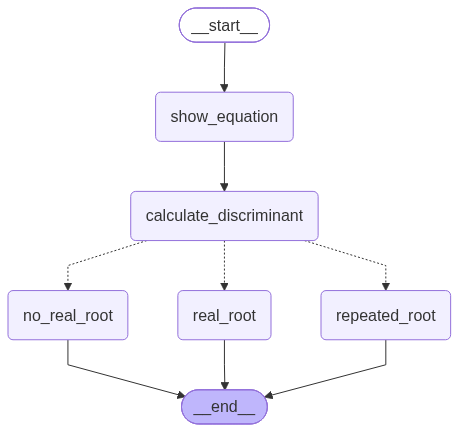

In [104]:
workflow


In [105]:
intial_state={
  'a':3,
  'b':-5,
  'c':-2

}

In [106]:
workflow.invoke(intial_state)


{'a': 3,
 'b': -5,
 'c': -2,
 'equation': '3x2-5x-2',
 'discriminant': 49,
 'result': 'The roots are 2.0 and -0.3333333333333333'}